In [1070]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn. ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor


In [1071]:
df = pd.read_excel("Dataset3.xlsx")

In [1072]:
df

,Sporcu_ID,Spor_Dalı,Deneyim_Yılı,Cinsiyet,Kulüp_Tipi,Motivasyon_Düzeyi,Beslenme_Tipi,Sakatlık_Durumu,Şehir,Antrenman_Sıklığı,...,Kilo_kg,VO2max,Dinlenim_Nabzı_bpm,Uyku_Saat,Antrenman_Yükü_dk,Sakatlık_Gün_Yıl,Protein_Alımı_gr,Sporcu_Bütçe_TL,Yarışma_Sayısı,Performans_Sınıfı
0,SPID0001,Futbol,2_3,Erkek,Bağımsız,Çok Yüksek,Sporcu Diyeti,0.0,İstanbul,Haftada 2-3,...,63.8,59.5,50.1,6.0,129.5,NaN,369.7,5809.0,8.0,0
1,SPID0002,Tenis,0_1,Erkek,Üniversite,Yüksek,Standart,1.0,NaN,Günde 2x,...,100.6,57.4,63.0,6.9,43.7,10.6,174.7,17078.0,1.0,3
2,SPID0003,Voleybol,7_10,Erkek,Milli Takım,Orta,Vejetaryen,NaN,İstanbul,Haftada 2-3,...,71.7,NaN,10.0,8.4,31.9,19.5,42.5,2252.0,9.0,1
3,SPID0004,Basketbol,4_6,Kadın,Milli Takım,Çok Yüksek,Sporcu Diyeti,2.0,NaN,Haftada 4-5,...,62.2,51.1,61.3,7.4,NaN,9.2,NaN,2956.0,NaN,0
4,SPID0005,Futbol,4_6,Erkek,Devlet Kulübü,Orta,Standart,0.0,İstanbul,Haftada 1,...,67.8,61.2,51.7,9.3,NaN,0.5,NaN,4031.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,SPID0596,Yüzme,2_3,Erkek,Üniversite,Çok Yüksek,Vejetaryen,3.0,NaN,Haftada 4-5,...,68.8,59.9,48.0,5.0,101.5,1.8,96.4,NaN,3.0,1
596,SPID0597,Voleybol,0_1,Erkek,Milli Takım,Orta,Sporcu Diyeti,NaN,İstanbul,Günde 2x,...,94.9,54.2,75.2,6.7,85.4,8.3,NaN,904.0,6.0,1
597,SPID0598,Güreş,7_10,Erkek,Üniversite,Yüksek,Sporcu Diyeti,3.0,NaN,Haftada 4-5,...,74.2,63.6,57.3,7.1,13.5,2.8,83.4,1983.0,11.0,1
598,SPID0599,Atletizm,0_1,Kadın,Özel Kulüp,Yüksek,Vejetaryen,0.0,NaN,Haftada 4-5,...,78.6,NaN,47.8,8.9,51.2,11.9,100.0,7938.0,1.0,2


In [1073]:
df.columns

Index(['Sporcu_ID', 'Spor_Dalı', 'Deneyim_Yılı', 'Cinsiyet', 'Kulüp_Tipi',
       'Motivasyon_Düzeyi', 'Beslenme_Tipi', 'Sakatlık_Durumu', 'Şehir',
       'Antrenman_Sıklığı', 'Antrenman_Yeri', 'Rakip_Seviyesi', 'Yaş',
       'Boy_cm', 'Kilo_kg', 'VO2max', 'Dinlenim_Nabzı_bpm', 'Uyku_Saat',
       'Antrenman_Yükü_dk', 'Sakatlık_Gün_Yıl', 'Protein_Alımı_gr',
       'Sporcu_Bütçe_TL', 'Yarışma_Sayısı', 'Performans_Sınıfı'],
      dtype='object')

In [1074]:
df["Performans_Sınıfı"].value_counts()

0    183
1    178
2    144
3     95
Name: Performans_Sınıfı, dtype: int64

In [1075]:
df.isnull().sum()

Sporcu_ID               0
Spor_Dalı               4
Deneyim_Yılı           17
Cinsiyet               10
Kulüp_Tipi             12
Motivasyon_Düzeyi      41
Beslenme_Tipi          37
Sakatlık_Durumu       583
Şehir                   5
Antrenman_Sıklığı      24
Antrenman_Yeri         29
Rakip_Seviyesi         24
Yaş                    14
Boy_cm                 35
Kilo_kg                33
VO2max                 53
Dinlenim_Nabzı_bpm     42
Uyku_Saat              30
Antrenman_Yükü_dk      52
Sakatlık_Gün_Yıl       68
Protein_Alımı_gr       59
Sporcu_Bütçe_TL        79
Yarışma_Sayısı         52
Performans_Sınıfı       0
dtype: int64

In [1076]:
df.dtypes

Sporcu_ID              object
Spor_Dalı              object
Deneyim_Yılı           object
Cinsiyet               object
Kulüp_Tipi             object
Motivasyon_Düzeyi      object
Beslenme_Tipi          object
Sakatlık_Durumu       float64
Şehir                  object
Antrenman_Sıklığı      object
Antrenman_Yeri         object
Rakip_Seviyesi         object
Yaş                   float64
Boy_cm                float64
Kilo_kg               float64
VO2max                float64
Dinlenim_Nabzı_bpm    float64
Uyku_Saat             float64
Antrenman_Yükü_dk     float64
Sakatlık_Gün_Yıl      float64
Protein_Alımı_gr      float64
Sporcu_Bütçe_TL       float64
Yarışma_Sayısı        float64
Performans_Sınıfı       int64
dtype: object

In [1077]:
df = df.drop("Sakatlık_Durumu",axis=1)
df.isnull().sum()

Sporcu_ID              0
Spor_Dalı              4
Deneyim_Yılı          17
Cinsiyet              10
Kulüp_Tipi            12
Motivasyon_Düzeyi     41
Beslenme_Tipi         37
Şehir                  5
Antrenman_Sıklığı     24
Antrenman_Yeri        29
Rakip_Seviyesi        24
Yaş                   14
Boy_cm                35
Kilo_kg               33
VO2max                53
Dinlenim_Nabzı_bpm    42
Uyku_Saat             30
Antrenman_Yükü_dk     52
Sakatlık_Gün_Yıl      68
Protein_Alımı_gr      59
Sporcu_Bütçe_TL       79
Yarışma_Sayısı        52
Performans_Sınıfı      0
dtype: int64

In [1078]:
df["Sporcu_ID"].value_counts()

SPID0001    1
SPID0395    1
SPID0397    1
SPID0398    1
SPID0399    1
           ..
SPID0201    1
SPID0202    1
SPID0203    1
SPID0204    1
SPID0600    1
Name: Sporcu_ID, Length: 600, dtype: int64

In [1079]:
df = df.drop("Sporcu_ID",axis=1)
df.isnull().sum()

Spor_Dalı              4
Deneyim_Yılı          17
Cinsiyet              10
Kulüp_Tipi            12
Motivasyon_Düzeyi     41
Beslenme_Tipi         37
Şehir                  5
Antrenman_Sıklığı     24
Antrenman_Yeri        29
Rakip_Seviyesi        24
Yaş                   14
Boy_cm                35
Kilo_kg               33
VO2max                53
Dinlenim_Nabzı_bpm    42
Uyku_Saat             30
Antrenman_Yükü_dk     52
Sakatlık_Gün_Yıl      68
Protein_Alımı_gr      59
Sporcu_Bütçe_TL       79
Yarışma_Sayısı        52
Performans_Sınıfı      0
dtype: int64

In [1080]:
df["Spor_Dalı"].value_counts()

Futbol       130
Atletizm     105
Basketbol     99
Voleybol      75
Yüzme         73
Tenis         66
Güreş         42
###            4
##             2
Name: Spor_Dalı, dtype: int64

In [1081]:
df = df.drop("Spor_Dalı",axis=1)
df.isnull().sum()

Deneyim_Yılı          17
Cinsiyet              10
Kulüp_Tipi            12
Motivasyon_Düzeyi     41
Beslenme_Tipi         37
Şehir                  5
Antrenman_Sıklığı     24
Antrenman_Yeri        29
Rakip_Seviyesi        24
Yaş                   14
Boy_cm                35
Kilo_kg               33
VO2max                53
Dinlenim_Nabzı_bpm    42
Uyku_Saat             30
Antrenman_Yükü_dk     52
Sakatlık_Gün_Yıl      68
Protein_Alımı_gr      59
Sporcu_Bütçe_TL       79
Yarışma_Sayısı        52
Performans_Sınıfı      0
dtype: int64

In [1082]:
df["Deneyim_Yılı"].value_counts()

4_6     157
7_10    131
2_3     128
0_1      89
10+      78
Name: Deneyim_Yılı, dtype: int64

In [1083]:
df["Cinsiyet"].value_counts()

Kadın    314
Erkek    276
Name: Cinsiyet, dtype: int64

In [1084]:
df["Kulüp_Tipi"].value_counts()

Özel Kulüp             170
Üniversite             129
Bağımsız               119
Devlet Kulübü          103
Milli Takım             60
Belediye Kulübü          2
Gençlik Spor Kulübü      2
Askeri Kulübü            2
Şirket Kulübü            1
Name: Kulüp_Tipi, dtype: int64

In [1085]:
kulup = df["Kulüp_Tipi"].value_counts()

In [1086]:
kulup

Özel Kulüp             170
Üniversite             129
Bağımsız               119
Devlet Kulübü          103
Milli Takım             60
Belediye Kulübü          2
Gençlik Spor Kulübü      2
Askeri Kulübü            2
Şirket Kulübü            1
Name: Kulüp_Tipi, dtype: int64

In [1087]:
nadir_kulup = kulup[kulup<5]
nadir_kulup

Belediye Kulübü        2
Gençlik Spor Kulübü    2
Askeri Kulübü          2
Şirket Kulübü          1
Name: Kulüp_Tipi, dtype: int64

In [1088]:
df["Kulüp_Tipi"]=df["Kulüp_Tipi"].replace(nadir_kulup.index,"diger")
df["Kulüp_Tipi"].value_counts()

Özel Kulüp       170
Üniversite       129
Bağımsız         119
Devlet Kulübü    103
Milli Takım       60
diger              7
Name: Kulüp_Tipi, dtype: int64

In [1089]:
df["Motivasyon_Düzeyi"].value_counts()

Yüksek        217
Orta          150
Çok Yüksek    109
Düşük          55
Çok Düşük      22
Çok Yuksek      6
Name: Motivasyon_Düzeyi, dtype: int64

In [1090]:
df["Motivasyon_Düzeyi"] = df["Motivasyon_Düzeyi"].replace("Çok Yüksek", "Çok Yuksek")
df["Motivasyon_Düzeyi"].value_counts()

Yüksek        217
Orta          150
Çok Yuksek    115
Düşük          55
Çok Düşük      22
Name: Motivasyon_Düzeyi, dtype: int64

In [1091]:
df["Beslenme_Tipi"].value_counts()

Sporcu Diyeti     212
Standart          126
Vejetaryen         92
Yüksek Protein     90
Vegan              43
Name: Beslenme_Tipi, dtype: int64

In [1092]:
df["Şehir"].value_counts()

İstanbul    595
Name: Şehir, dtype: int64

In [1093]:
df = df.drop("Şehir",axis=1)
df.isnull().sum()

Deneyim_Yılı          17
Cinsiyet              10
Kulüp_Tipi            12
Motivasyon_Düzeyi     41
Beslenme_Tipi         37
Antrenman_Sıklığı     24
Antrenman_Yeri        29
Rakip_Seviyesi        24
Yaş                   14
Boy_cm                35
Kilo_kg               33
VO2max                53
Dinlenim_Nabzı_bpm    42
Uyku_Saat             30
Antrenman_Yükü_dk     52
Sakatlık_Gün_Yıl      68
Protein_Alımı_gr      59
Sporcu_Bütçe_TL       79
Yarışma_Sayısı        52
Performans_Sınıfı      0
dtype: int64

In [1094]:
df["Antrenman_Sıklığı"].value_counts()

Haftada 4-5    186
Her Gün        141
Haftada 2-3    123
Günde 2x        72
Haftada 1       54
Name: Antrenman_Sıklığı, dtype: int64

In [1095]:
df["Antrenman_Yeri"].value_counts()

Kapalı Salon         140
Profesyonel Tesis    137
Açık Alan            119
Karma                118
Ev                    57
Name: Antrenman_Yeri, dtype: int64

In [1096]:
df["Rakip_Seviyesi"].value_counts()

Orta         184
Yüksek       154
Düşük        106
Elit          85
Çok Düşük     47
Name: Rakip_Seviyesi, dtype: int64

In [1097]:
df.isnull().sum()

Deneyim_Yılı          17
Cinsiyet              10
Kulüp_Tipi            12
Motivasyon_Düzeyi     41
Beslenme_Tipi         37
Antrenman_Sıklığı     24
Antrenman_Yeri        29
Rakip_Seviyesi        24
Yaş                   14
Boy_cm                35
Kilo_kg               33
VO2max                53
Dinlenim_Nabzı_bpm    42
Uyku_Saat             30
Antrenman_Yükü_dk     52
Sakatlık_Gün_Yıl      68
Protein_Alımı_gr      59
Sporcu_Bütçe_TL       79
Yarışma_Sayısı        52
Performans_Sınıfı      0
dtype: int64

In [1098]:
df.dtypes

Deneyim_Yılı           object
Cinsiyet               object
Kulüp_Tipi             object
Motivasyon_Düzeyi      object
Beslenme_Tipi          object
Antrenman_Sıklığı      object
Antrenman_Yeri         object
Rakip_Seviyesi         object
Yaş                   float64
Boy_cm                float64
Kilo_kg               float64
VO2max                float64
Dinlenim_Nabzı_bpm    float64
Uyku_Saat             float64
Antrenman_Yükü_dk     float64
Sakatlık_Gün_Yıl      float64
Protein_Alımı_gr      float64
Sporcu_Bütçe_TL       float64
Yarışma_Sayısı        float64
Performans_Sınıfı       int64
dtype: object

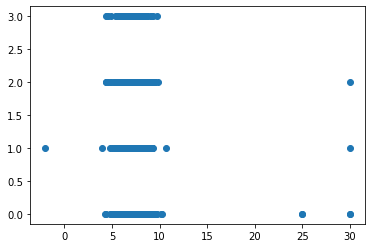

In [1099]:
plt.scatter(df["Uyku_Saat"],df["Performans_Sınıfı"])

In [1100]:
df

,Deneyim_Yılı,Cinsiyet,Kulüp_Tipi,Motivasyon_Düzeyi,Beslenme_Tipi,Antrenman_Sıklığı,Antrenman_Yeri,Rakip_Seviyesi,Yaş,Boy_cm,Kilo_kg,VO2max,Dinlenim_Nabzı_bpm,Uyku_Saat,Antrenman_Yükü_dk,Sakatlık_Gün_Yıl,Protein_Alımı_gr,Sporcu_Bütçe_TL,Yarışma_Sayısı,Performans_Sınıfı
0,2_3,Erkek,Bağımsız,Çok Yuksek,Sporcu Diyeti,Haftada 2-3,Kapalı Salon,Yüksek,23.5,180.1,63.8,59.5,50.1,6.0,129.5,NaN,369.7,5809.0,8.0,0
1,0_1,Erkek,Üniversite,Yüksek,Standart,Günde 2x,Karma,Yüksek,14.0,182.5,100.6,57.4,63.0,6.9,43.7,10.6,174.7,17078.0,1.0,3
2,7_10,Erkek,Milli Takım,Orta,Vejetaryen,Haftada 2-3,Karma,Elit,26.2,169.6,71.7,NaN,10.0,8.4,31.9,19.5,42.5,2252.0,9.0,1
3,4_6,Kadın,Milli Takım,Çok Yuksek,Sporcu Diyeti,Haftada 4-5,Açık Alan,Orta,22.7,182.8,62.2,51.1,61.3,7.4,NaN,9.2,NaN,2956.0,NaN,0
4,4_6,Erkek,Devlet Kulübü,Orta,Standart,Haftada 1,Kapalı Salon,Düşük,16.1,171.3,67.8,61.2,51.7,9.3,NaN,0.5,NaN,4031.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,2_3,Erkek,Üniversite,Çok Yuksek,Vejetaryen,Haftada 4-5,Ev,Yüksek,18.1,189.9,68.8,59.9,48.0,5.0,101.5,1.8,96.4,NaN,3.0,1
596,0_1,Erkek,Milli Takım,Orta,Sporcu Diyeti,Günde 2x,Profesyonel Tesis,Yüksek,27.0,172.4,94.9,54.2,75.2,6.7,85.4,8.3,NaN,904.0,6.0,1
597,7_10,Erkek,Üniversite,Yüksek,Sporcu Diyeti,Haftada 4-5,Profesyonel Tesis,Orta,14.0,NaN,74.2,63.6,57.3,7.1,13.5,2.8,83.4,1983.0,11.0,1
598,0_1,Kadın,Özel Kulüp,Yüksek,Vejetaryen,Haftada 4-5,Ev,Orta,18.1,177.2,78.6,NaN,47.8,8.9,51.2,11.9,100.0,7938.0,1.0,2


In [1101]:
x = df.groupby(["Kulüp_Tipi", "Cinsiyet"])["Deneyim_Yılı"].transform(
    lambda x: x.mode()[0]
)
df["Deneyim_Yılı"] = df["Deneyim_Yılı"].fillna(x)
df["Deneyim_Yılı"].isnull().sum()

0

In [1119]:
x = df.groupby(["Deneyim_Yılı"])["Kulüp_Tipi"].transform(
    lambda x: x.mode()[0]
)
df["Kulüp_Tipi"] = df["Kulüp_Tipi"].fillna(x)
df["Kulüp_Tipi"].isnull().sum()

0

In [1120]:
x = df.groupby(["Deneyim_Yılı"])["Motivasyon_Düzeyi"].transform(
    lambda x: x.mode()[0]
)
df["Motivasyon_Düzeyi"] = df["Motivasyon_Düzeyi"].fillna(x)
df["Motivasyon_Düzeyi"].isnull().sum()

0

In [1121]:
x = df.groupby(["Deneyim_Yılı","Kulüp_Tipi"])["Beslenme_Tipi"].transform(
    lambda x: x.mode()[0]
)
df["Beslenme_Tipi"] = df["Beslenme_Tipi"].fillna(x)
df["Beslenme_Tipi"].isnull().sum()

0

In [1122]:
x = df.groupby(["Deneyim_Yılı","Kulüp_Tipi"])["Antrenman_Sıklığı"].transform(
    lambda x: x.mode()[0]
)
df["Antrenman_Sıklığı"] = df["Antrenman_Sıklığı"].fillna(x)
df["Antrenman_Sıklığı"].isnull().sum()

0

In [1123]:
x = df.groupby(["Deneyim_Yılı","Kulüp_Tipi"])["Antrenman_Yeri"].transform(
    lambda x: x.mode()[0]
)
df["Antrenman_Yeri"] = df["Antrenman_Yeri"].fillna(x)
df["Antrenman_Yeri"].isnull().sum()

0

In [1124]:
x = df.groupby(["Deneyim_Yılı","Kulüp_Tipi"])["Rakip_Seviyesi"].transform(
    lambda x: x.mode()[0]
)
df["Rakip_Seviyesi"] = df["Rakip_Seviyesi"].fillna(x)
df["Rakip_Seviyesi"].isnull().sum()

0

In [1125]:
df.isnull().sum()

Deneyim_Yılı           0
Cinsiyet               0
Kulüp_Tipi             0
Motivasyon_Düzeyi      0
Beslenme_Tipi          0
Antrenman_Sıklığı      0
Antrenman_Yeri         0
Rakip_Seviyesi         0
Yaş                    0
Boy_cm                 0
Kilo_kg                0
VO2max                 0
Dinlenim_Nabzı_bpm     0
Uyku_Saat              0
Antrenman_Yükü_dk      0
Sakatlık_Gün_Yıl       0
Protein_Alımı_gr      59
Sporcu_Bütçe_TL       79
Yarışma_Sayısı        52
Performans_Sınıfı      0
dtype: int64

In [1126]:
x = df.groupby(["Kulüp_Tipi"])["Cinsiyet"].transform(
    lambda x: x.mode()[0]
)
df["Cinsiyet"] = df["Cinsiyet"].fillna(x)
df["Cinsiyet"].isnull().sum()

0

In [1127]:
df.isnull().sum()

Deneyim_Yılı           0
Cinsiyet               0
Kulüp_Tipi             0
Motivasyon_Düzeyi      0
Beslenme_Tipi          0
Antrenman_Sıklığı      0
Antrenman_Yeri         0
Rakip_Seviyesi         0
Yaş                    0
Boy_cm                 0
Kilo_kg                0
VO2max                 0
Dinlenim_Nabzı_bpm     0
Uyku_Saat              0
Antrenman_Yükü_dk      0
Sakatlık_Gün_Yıl       0
Protein_Alımı_gr      59
Sporcu_Bütçe_TL       79
Yarışma_Sayısı        52
Performans_Sınıfı      0
dtype: int64

In [1128]:
x = df.groupby(["Kulüp_Tipi"])["Yaş"].transform("median")
df["Yaş"] = df["Yaş"].fillna(x)
df["Yaş"].isnull().sum()

0

In [1129]:
x = df.groupby(["Kulüp_Tipi"])["Boy_cm"].transform("median")
df["Boy_cm"] = df["Boy_cm"].fillna(x)
df["Boy_cm"].isnull().sum()

0

In [1130]:
x = df.groupby(["Cinsiyet"])["Kilo_kg"].transform("median")
df["Kilo_kg"] = df["Kilo_kg"].fillna(x)
df["Kilo_kg"].isnull().sum()

0

In [1131]:
x = df.groupby(["Cinsiyet"])["VO2max"].transform("median")
df["VO2max"] = df["VO2max"].fillna(x)
df["VO2max"].isnull().sum()

0

In [1132]:
x = df.groupby(["Cinsiyet"])["Dinlenim_Nabzı_bpm"].transform("median")
df["Dinlenim_Nabzı_bpm"] = df["Dinlenim_Nabzı_bpm"].fillna(x)
df["Dinlenim_Nabzı_bpm"].isnull().sum()

0

In [1133]:
x = df.groupby(["Cinsiyet"])["Uyku_Saat"].transform("median")
df["Uyku_Saat"] = df["Uyku_Saat"].fillna(x)
df["Uyku_Saat"].isnull().sum()

0

In [1134]:
x = df.groupby(["Cinsiyet"])["Antrenman_Yükü_dk"].transform("median")
df["Antrenman_Yükü_dk"] = df["Antrenman_Yükü_dk"].fillna(x)
df["Antrenman_Yükü_dk"].isnull().sum()

0

In [1135]:
x = df.groupby(["Cinsiyet"])["Sakatlık_Gün_Yıl"].transform("median")
df["Sakatlık_Gün_Yıl"] = df["Sakatlık_Gün_Yıl"].fillna(x)
df["Sakatlık_Gün_Yıl"].isnull().sum()

0

In [1136]:
x = df.groupby(["Cinsiyet"])["Protein_Alımı_gr"].transform("median")
df["Protein_Alımı_gr"] = df["Protein_Alımı_gr"].fillna(x)
df["Protein_Alımı_gr"].isnull().sum()

0

In [1137]:
x = df.groupby(["Cinsiyet"])["Sporcu_Bütçe_TL"].transform("median")
df["Sporcu_Bütçe_TL"] = df["Sporcu_Bütçe_TL"].fillna(x)
df["Sporcu_Bütçe_TL"].isnull().sum()

0

In [1138]:
x = df.groupby(["Cinsiyet"])["Yarışma_Sayısı"].transform("median")
df["Yarışma_Sayısı"] = df["Yarışma_Sayısı"].fillna(x)
df["Yarışma_Sayısı"].isnull().sum()

0

In [1139]:
df.isnull().sum()

Deneyim_Yılı          0
Cinsiyet              0
Kulüp_Tipi            0
Motivasyon_Düzeyi     0
Beslenme_Tipi         0
Antrenman_Sıklığı     0
Antrenman_Yeri        0
Rakip_Seviyesi        0
Yaş                   0
Boy_cm                0
Kilo_kg               0
VO2max                0
Dinlenim_Nabzı_bpm    0
Uyku_Saat             0
Antrenman_Yükü_dk     0
Sakatlık_Gün_Yıl      0
Protein_Alımı_gr      0
Sporcu_Bütçe_TL       0
Yarışma_Sayısı        0
Performans_Sınıfı     0
dtype: int64

In [1140]:
df = pd.get_dummies(df, columns=["Kulüp_Tipi","Beslenme_Tipi","Antrenman_Yeri"], drop_first=True, dtype=int)
df

,Deneyim_Yılı,Cinsiyet,Motivasyon_Düzeyi,Antrenman_Sıklığı,Rakip_Seviyesi,Yaş,Boy_cm,Kilo_kg,VO2max,Dinlenim_Nabzı_bpm,...,Kulüp_Tipi_Özel Kulüp,Kulüp_Tipi_Üniversite,Beslenme_Tipi_Standart,Beslenme_Tipi_Vegan,Beslenme_Tipi_Vejetaryen,Beslenme_Tipi_Yüksek Protein,Antrenman_Yeri_Ev,Antrenman_Yeri_Kapalı Salon,Antrenman_Yeri_Karma,Antrenman_Yeri_Profesyonel Tesis
0,2_3,Erkek,Çok Yuksek,Haftada 2-3,Yüksek,23.5,180.1,63.8,59.50,50.1,...,0,0,0,0,0,0,0,1,0,0
1,0_1,Erkek,Yüksek,Günde 2x,Yüksek,14.0,182.5,100.6,57.40,63.0,...,0,1,1,0,0,0,0,0,1,0
2,7_10,Erkek,Orta,Haftada 2-3,Elit,26.2,169.6,71.7,52.20,10.0,...,0,0,0,0,1,0,0,0,1,0
3,4_6,Kadın,Çok Yuksek,Haftada 4-5,Orta,22.7,182.8,62.2,51.10,61.3,...,0,0,0,0,0,0,0,0,0,0
4,4_6,Erkek,Orta,Haftada 1,Düşük,16.1,171.3,67.8,61.20,51.7,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,2_3,Erkek,Çok Yuksek,Haftada 4-5,Yüksek,18.1,189.9,68.8,59.90,48.0,...,0,1,0,0,1,0,1,0,0,0
596,0_1,Erkek,Orta,Günde 2x,Yüksek,27.0,172.4,94.9,54.20,75.2,...,0,0,0,0,0,0,0,0,0,1
597,7_10,Erkek,Yüksek,Haftada 4-5,Orta,14.0,179.3,74.2,63.60,57.3,...,0,1,0,0,0,0,0,0,0,1
598,0_1,Kadın,Yüksek,Haftada 4-5,Orta,18.1,177.2,78.6,51.55,47.8,...,1,0,0,0,1,0,1,0,0,0


In [1141]:
(df["Deneyim_Yılı"])=df["Deneyim_Yılı"].map({
    
    "4_6":2,     
    "7_10":3,    
    "2_3":1,     
    "0_1":0,   
    "10+":4        
})
(df["Cinsiyet"])=df["Cinsiyet"].map({
    
    "Erkek":0,     
    "Kadın":1,            
})
(df["Motivasyon_Düzeyi"])=df["Motivasyon_Düzeyi"].map({
    "Yüksek":3,        
    "Orta ":2,         
    "Çok Yuksek":4,    
    "Düşük":1,          
    "Çok Düşük":0      
       
})
(df["Rakip_Seviyesi"])=df["Rakip_Seviyesi"].map({
    "Orta":2,         
    "Yüksek":1,       
    "Düşük":3,      
    "Elit":0,          
    "Çok Düşük":4,     
        
       
})

In [1142]:
df

,Deneyim_Yılı,Cinsiyet,Motivasyon_Düzeyi,Antrenman_Sıklığı,Rakip_Seviyesi,Yaş,Boy_cm,Kilo_kg,VO2max,Dinlenim_Nabzı_bpm,...,Kulüp_Tipi_Özel Kulüp,Kulüp_Tipi_Üniversite,Beslenme_Tipi_Standart,Beslenme_Tipi_Vegan,Beslenme_Tipi_Vejetaryen,Beslenme_Tipi_Yüksek Protein,Antrenman_Yeri_Ev,Antrenman_Yeri_Kapalı Salon,Antrenman_Yeri_Karma,Antrenman_Yeri_Profesyonel Tesis
0,1,0,4.0,Haftada 2-3,1,23.5,180.1,63.8,59.50,50.1,...,0,0,0,0,0,0,0,1,0,0
1,0,0,3.0,Günde 2x,1,14.0,182.5,100.6,57.40,63.0,...,0,1,1,0,0,0,0,0,1,0
2,3,0,NaN,Haftada 2-3,0,26.2,169.6,71.7,52.20,10.0,...,0,0,0,0,1,0,0,0,1,0
3,2,1,4.0,Haftada 4-5,2,22.7,182.8,62.2,51.10,61.3,...,0,0,0,0,0,0,0,0,0,0
4,2,0,NaN,Haftada 1,3,16.1,171.3,67.8,61.20,51.7,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,1,0,4.0,Haftada 4-5,1,18.1,189.9,68.8,59.90,48.0,...,0,1,0,0,1,0,1,0,0,0
596,0,0,NaN,Günde 2x,1,27.0,172.4,94.9,54.20,75.2,...,0,0,0,0,0,0,0,0,0,1
597,3,0,3.0,Haftada 4-5,2,14.0,179.3,74.2,63.60,57.3,...,0,1,0,0,0,0,0,0,0,1
598,0,1,3.0,Haftada 4-5,2,18.1,177.2,78.6,51.55,47.8,...,1,0,0,0,1,0,1,0,0,0


In [1143]:
(df["Antrenman_Sıklığı"])=df["Antrenman_Sıklığı"].map({
    "Haftada 4-5":2,    
    "Her Gün":3,        
    "Haftada 2-3":1,    
    "Günde 2x":4,        
    "Haftada 1":0       
 
       
})
df

,Deneyim_Yılı,Cinsiyet,Motivasyon_Düzeyi,Antrenman_Sıklığı,Rakip_Seviyesi,Yaş,Boy_cm,Kilo_kg,VO2max,Dinlenim_Nabzı_bpm,...,Kulüp_Tipi_Özel Kulüp,Kulüp_Tipi_Üniversite,Beslenme_Tipi_Standart,Beslenme_Tipi_Vegan,Beslenme_Tipi_Vejetaryen,Beslenme_Tipi_Yüksek Protein,Antrenman_Yeri_Ev,Antrenman_Yeri_Kapalı Salon,Antrenman_Yeri_Karma,Antrenman_Yeri_Profesyonel Tesis
0,1,0,4.0,1,1,23.5,180.1,63.8,59.50,50.1,...,0,0,0,0,0,0,0,1,0,0
1,0,0,3.0,4,1,14.0,182.5,100.6,57.40,63.0,...,0,1,1,0,0,0,0,0,1,0
2,3,0,NaN,1,0,26.2,169.6,71.7,52.20,10.0,...,0,0,0,0,1,0,0,0,1,0
3,2,1,4.0,2,2,22.7,182.8,62.2,51.10,61.3,...,0,0,0,0,0,0,0,0,0,0
4,2,0,NaN,0,3,16.1,171.3,67.8,61.20,51.7,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,1,0,4.0,2,1,18.1,189.9,68.8,59.90,48.0,...,0,1,0,0,1,0,1,0,0,0
596,0,0,NaN,4,1,27.0,172.4,94.9,54.20,75.2,...,0,0,0,0,0,0,0,0,0,1
597,3,0,3.0,2,2,14.0,179.3,74.2,63.60,57.3,...,0,1,0,0,0,0,0,0,0,1
598,0,1,3.0,2,2,18.1,177.2,78.6,51.55,47.8,...,1,0,0,0,1,0,1,0,0,0


In [1144]:
df.dtypes

Deneyim_Yılı                          int64
Cinsiyet                              int64
Motivasyon_Düzeyi                   float64
Antrenman_Sıklığı                     int64
Rakip_Seviyesi                        int64
Yaş                                 float64
Boy_cm                              float64
Kilo_kg                             float64
VO2max                              float64
Dinlenim_Nabzı_bpm                  float64
Uyku_Saat                           float64
Antrenman_Yükü_dk                   float64
Sakatlık_Gün_Yıl                    float64
Protein_Alımı_gr                    float64
Sporcu_Bütçe_TL                     float64
Yarışma_Sayısı                      float64
Performans_Sınıfı                     int64
Kulüp_Tipi_Devlet Kulübü              int32
Kulüp_Tipi_Milli Takım                int32
Kulüp_Tipi_diger                      int32
Kulüp_Tipi_Özel Kulüp                 int32
Kulüp_Tipi_Üniversite                 int32
Beslenme_Tipi_Standart          

In [1145]:
df.isnull().sum()

Deneyim_Yılı                          0
Cinsiyet                              0
Motivasyon_Düzeyi                   163
Antrenman_Sıklığı                     0
Rakip_Seviyesi                        0
Yaş                                   0
Boy_cm                                0
Kilo_kg                               0
VO2max                                0
Dinlenim_Nabzı_bpm                    0
Uyku_Saat                             0
Antrenman_Yükü_dk                     0
Sakatlık_Gün_Yıl                      0
Protein_Alımı_gr                      0
Sporcu_Bütçe_TL                       0
Yarışma_Sayısı                        0
Performans_Sınıfı                     0
Kulüp_Tipi_Devlet Kulübü              0
Kulüp_Tipi_Milli Takım                0
Kulüp_Tipi_diger                      0
Kulüp_Tipi_Özel Kulüp                 0
Kulüp_Tipi_Üniversite                 0
Beslenme_Tipi_Standart                0
Beslenme_Tipi_Vegan                   0
Beslenme_Tipi_Vejetaryen              0


In [1146]:
x = df.groupby(["Rakip_Seviyesi"])["Motivasyon_Düzeyi"].transform("median")
df["Motivasyon_Düzeyi"] = df["Motivasyon_Düzeyi"].fillna(x)
df["Motivasyon_Düzeyi"].isnull().sum()

0

In [1147]:
df.isnull().sum()

Deneyim_Yılı                        0
Cinsiyet                            0
Motivasyon_Düzeyi                   0
Antrenman_Sıklığı                   0
Rakip_Seviyesi                      0
Yaş                                 0
Boy_cm                              0
Kilo_kg                             0
VO2max                              0
Dinlenim_Nabzı_bpm                  0
Uyku_Saat                           0
Antrenman_Yükü_dk                   0
Sakatlık_Gün_Yıl                    0
Protein_Alımı_gr                    0
Sporcu_Bütçe_TL                     0
Yarışma_Sayısı                      0
Performans_Sınıfı                   0
Kulüp_Tipi_Devlet Kulübü            0
Kulüp_Tipi_Milli Takım              0
Kulüp_Tipi_diger                    0
Kulüp_Tipi_Özel Kulüp               0
Kulüp_Tipi_Üniversite               0
Beslenme_Tipi_Standart              0
Beslenme_Tipi_Vegan                 0
Beslenme_Tipi_Vejetaryen            0
Beslenme_Tipi_Yüksek Protein        0
Antrenman_Ye

In [1148]:
df.dtypes

Deneyim_Yılı                          int64
Cinsiyet                              int64
Motivasyon_Düzeyi                   float64
Antrenman_Sıklığı                     int64
Rakip_Seviyesi                        int64
Yaş                                 float64
Boy_cm                              float64
Kilo_kg                             float64
VO2max                              float64
Dinlenim_Nabzı_bpm                  float64
Uyku_Saat                           float64
Antrenman_Yükü_dk                   float64
Sakatlık_Gün_Yıl                    float64
Protein_Alımı_gr                    float64
Sporcu_Bütçe_TL                     float64
Yarışma_Sayısı                      float64
Performans_Sınıfı                     int64
Kulüp_Tipi_Devlet Kulübü              int32
Kulüp_Tipi_Milli Takım                int32
Kulüp_Tipi_diger                      int32
Kulüp_Tipi_Özel Kulüp                 int32
Kulüp_Tipi_Üniversite                 int32
Beslenme_Tipi_Standart          

In [1149]:
X = df.drop("Performans_Sınıfı", axis = 1)
Y = df["Performans_Sınıfı"]

In [1150]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [1151]:
model = RandomForestClassifier(n_estimators=100, max_depth=10)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
acc = accuracy_score(y_test, y_pred)
acc

0.3416666666666667

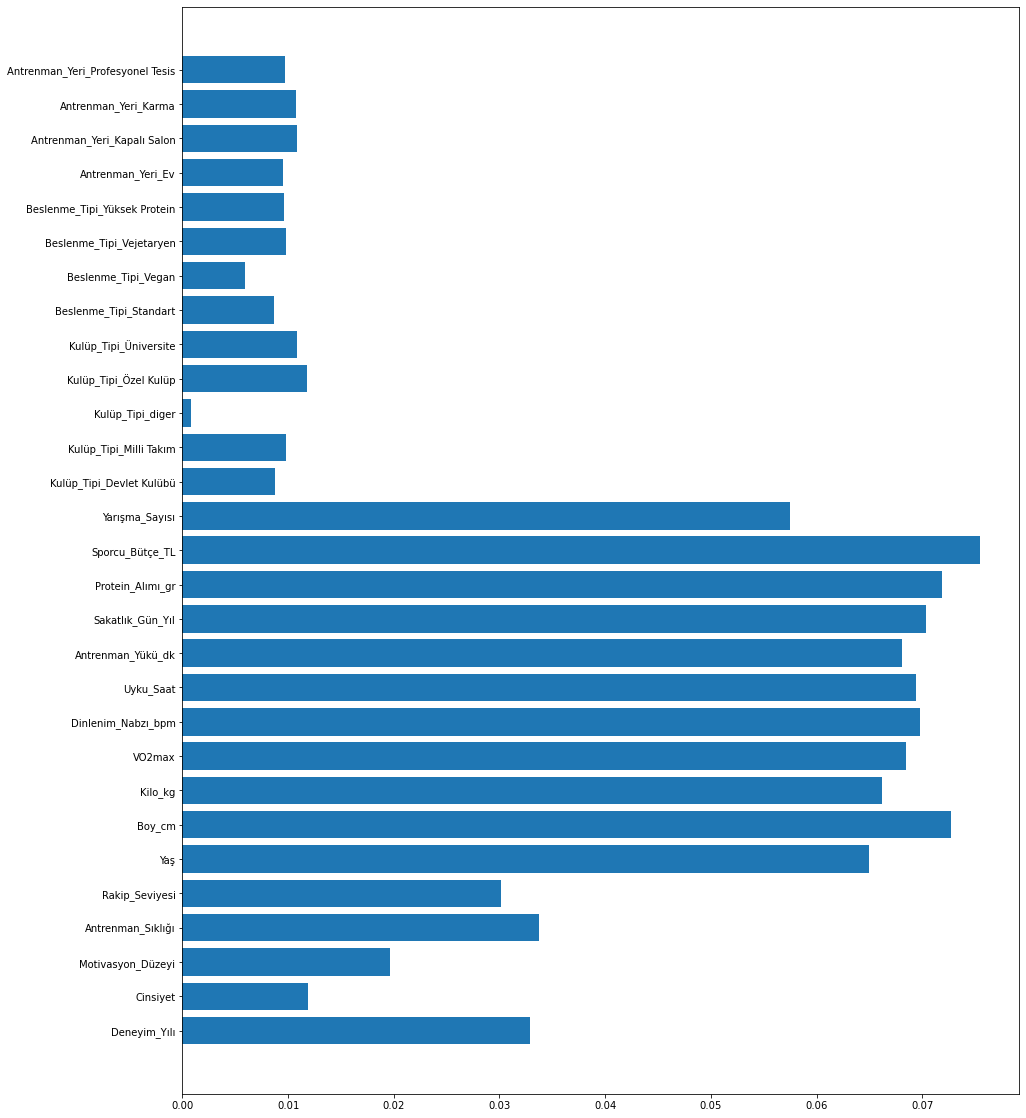

In [1152]:
import matplotlib.pyplot as plt
onem_dereceleri = model.feature_importances_
plt.figure(figsize=(15, 20))
plt.barh(X.columns, onem_dereceleri);

In [1153]:
onem_dereceleri

array([0.03286205, 0.0119097 , 0.01962214, 0.03369195, 0.03016834,
       0.06498247, 0.07273563, 0.06623748, 0.06850499, 0.06981862,
       0.0694574 , 0.06811776, 0.07038949, 0.07190419, 0.07543027,
       0.05752498, 0.00875366, 0.00977523, 0.00078093, 0.01174221,
       0.01087295, 0.00869265, 0.00589928, 0.00979997, 0.00960376,
       0.00953756, 0.01079357, 0.01072779, 0.009663  ])

In [1154]:
df.columns

Index(['Deneyim_Yılı', 'Cinsiyet', 'Motivasyon_Düzeyi', 'Antrenman_Sıklığı',
       'Rakip_Seviyesi', 'Yaş', 'Boy_cm', 'Kilo_kg', 'VO2max',
       'Dinlenim_Nabzı_bpm', 'Uyku_Saat', 'Antrenman_Yükü_dk',
       'Sakatlık_Gün_Yıl', 'Protein_Alımı_gr', 'Sporcu_Bütçe_TL',
       'Yarışma_Sayısı', 'Performans_Sınıfı', 'Kulüp_Tipi_Devlet Kulübü',
       'Kulüp_Tipi_Milli Takım', 'Kulüp_Tipi_diger', 'Kulüp_Tipi_Özel Kulüp',
       'Kulüp_Tipi_Üniversite', 'Beslenme_Tipi_Standart',
       'Beslenme_Tipi_Vegan', 'Beslenme_Tipi_Vejetaryen',
       'Beslenme_Tipi_Yüksek Protein', 'Antrenman_Yeri_Ev',
       'Antrenman_Yeri_Kapalı Salon', 'Antrenman_Yeri_Karma',
       'Antrenman_Yeri_Profesyonel Tesis'],
      dtype='object')

In [1155]:
x = df.drop("Kulüp_Tipi_diger",axis=1)
x = df.drop("Kulüp_Tipi_Milli Takım",axis=1)
x = df.drop("Antrenman_Yeri_Ev",axis=1)
x = df.drop("Beslenme_Tipi_Yüksek Protein",axis=1)
x = df.drop("Beslenme_Tipi_Vejetaryen",axis=1)
x = df.drop("Beslenme_Tipi_Vegan",axis=1)

In [1156]:
df

,Deneyim_Yılı,Cinsiyet,Motivasyon_Düzeyi,Antrenman_Sıklığı,Rakip_Seviyesi,Yaş,Boy_cm,Kilo_kg,VO2max,Dinlenim_Nabzı_bpm,...,Kulüp_Tipi_Özel Kulüp,Kulüp_Tipi_Üniversite,Beslenme_Tipi_Standart,Beslenme_Tipi_Vegan,Beslenme_Tipi_Vejetaryen,Beslenme_Tipi_Yüksek Protein,Antrenman_Yeri_Ev,Antrenman_Yeri_Kapalı Salon,Antrenman_Yeri_Karma,Antrenman_Yeri_Profesyonel Tesis
0,1,0,4.0,1,1,23.5,180.1,63.8,59.50,50.1,...,0,0,0,0,0,0,0,1,0,0
1,0,0,3.0,4,1,14.0,182.5,100.6,57.40,63.0,...,0,1,1,0,0,0,0,0,1,0
2,3,0,3.0,1,0,26.2,169.6,71.7,52.20,10.0,...,0,0,0,0,1,0,0,0,1,0
3,2,1,4.0,2,2,22.7,182.8,62.2,51.10,61.3,...,0,0,0,0,0,0,0,0,0,0
4,2,0,3.0,0,3,16.1,171.3,67.8,61.20,51.7,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,1,0,4.0,2,1,18.1,189.9,68.8,59.90,48.0,...,0,1,0,0,1,0,1,0,0,0
596,0,0,3.0,4,1,27.0,172.4,94.9,54.20,75.2,...,0,0,0,0,0,0,0,0,0,1
597,3,0,3.0,2,2,14.0,179.3,74.2,63.60,57.3,...,0,1,0,0,0,0,0,0,0,1
598,0,1,3.0,2,2,18.1,177.2,78.6,51.55,47.8,...,1,0,0,0,1,0,1,0,0,0


In [1161]:
sutunlar = ["Yaş","Boy_cm","Kilo_kg","VO2max","Dinlenim_Nabzı_bpm","Uyku_Saat","Antrenman_Yükü_dk",
           "Protein_Alımı_gr","Sporcu_Bütçe_TL","Yarışma_Sayısı"]

for sutun in sutunlar:
    print(f"{sutun}----{df[sutun].skew()}")

Yaş-----1.2293897369985063
Boy_cm-----1.9189851717216597
Kilo_kg-----3.8560989770507623
VO2max----1.6057864406911413
Dinlenim_Nabzı_bpm----2.8907711066347583
Uyku_Saat----6.557488791215846
Antrenman_Yükü_dk----1.9780139738825973
Protein_Alımı_gr----2.007238621853424
Sporcu_Bütçe_TL----8.351661323604391
Yarışma_Sayısı----2.2473060232885835


In [1162]:
df["Yaş"] = np.log1p(df["Yaş"])
df["Yaş"].skew()

-3.322724458456853

In [1163]:
df["Kilo_kg"] = np.log1p(df["Kilo_kg"])
df["Kilo_kg"].skew()

-5.775885038145284

In [1164]:
df["Dinlenim_Nabzı_bpm"] = np.log1p(df["Dinlenim_Nabzı_bpm"])
df["Dinlenim_Nabzı_bpm"].skew()

-4.070033874862815

In [1165]:
df["Uyku_Saat"] = np.log1p(df["Uyku_Saat"])
df["Uyku_Saat"].skew()

C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\arraylike.py:397: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


2.7262817292158226

In [1166]:
df["Protein_Alımı_gr"] = np.log1p(df["Protein_Alımı_gr"])
df["Protein_Alımı_gr"].skew()

0.5946194951721039

In [1167]:
df["Sporcu_Bütçe_TL"] = np.log1p(df["Sporcu_Bütçe_TL"])
df["Sporcu_Bütçe_TL"].skew()

-0.010482348995872364

In [1168]:
df["Yarışma_Sayısı"] = np.log1p(df["Yarışma_Sayısı"])
df["Yarışma_Sayısı"].skew()

-0.18732518600796327

In [1169]:
for sutun in sutunlar:
    Q1 = df[sutun].quantile(0.25)                      
    Q3 = df[sutun].quantile(0.75)  

    IQR = Q3 - Q1

    alt_sinir =Q1 - 1.5*IQR
    ust_sinir =Q3 + 1.5*IQR

    df[sutun] = df[sutun].clip(lower=alt_sinir,upper=ust_sinir)

{'whiskers': [<matplotlib.lines.Line2D at 0x2000c332100>,
 'caps': [<matplotlib.lines.Line2D at 0x2000c3326a0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2000c323df0>],
 'medians': [<matplotlib.lines.Line2D at 0x2000c332c40>],
 'fliers': [<matplotlib.lines.Line2D at 0x2000c332f10>],
 'means': []}

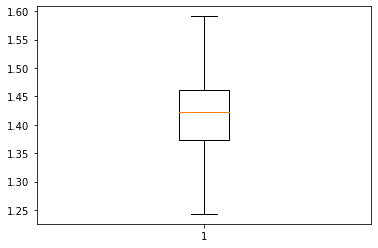

In [1170]:
plt.boxplot(df["Yaş"])

{'whiskers': [<matplotlib.lines.Line2D at 0x2000c390880>,
 'caps': [<matplotlib.lines.Line2D at 0x2000c390e50>,
 'boxes': [<matplotlib.lines.Line2D at 0x2000c3906d0>],
 'medians': [<matplotlib.lines.Line2D at 0x2000c39d430>],
 'fliers': [<matplotlib.lines.Line2D at 0x2000c39d700>],
 'means': []}

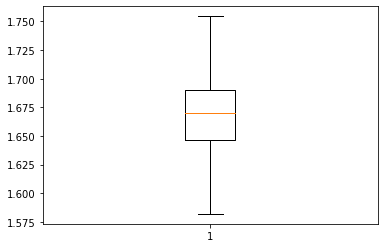

In [1171]:
plt.boxplot(df["Kilo_kg"])

{'whiskers': [<matplotlib.lines.Line2D at 0x2000c3f77f0>,
 'caps': [<matplotlib.lines.Line2D at 0x2000c3f7d90>,
 'boxes': [<matplotlib.lines.Line2D at 0x2000c3f7520>],
 'medians': [<matplotlib.lines.Line2D at 0x2000c403370>],
 'fliers': [<matplotlib.lines.Line2D at 0x2000c403640>],
 'means': []}

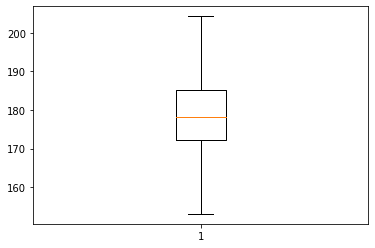

In [1172]:
plt.boxplot(df["Boy_cm"])

{'whiskers': [<matplotlib.lines.Line2D at 0x2000c459280>,
 'caps': [<matplotlib.lines.Line2D at 0x2000c459820>,
 'boxes': [<matplotlib.lines.Line2D at 0x2000c44bf70>],
 'medians': [<matplotlib.lines.Line2D at 0x2000c459dc0>],
 'fliers': [<matplotlib.lines.Line2D at 0x2000c4690d0>],
 'means': []}

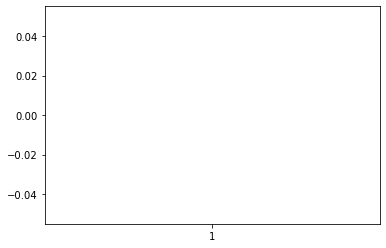

In [1173]:
plt.boxplot(df["Uyku_Saat"])

{'whiskers': [<matplotlib.lines.Line2D at 0x2000c4adcd0>,
 'caps': [<matplotlib.lines.Line2D at 0x2000c4bd2b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2000c4adb20>],
 'medians': [<matplotlib.lines.Line2D at 0x2000c4bd850>],
 'fliers': [<matplotlib.lines.Line2D at 0x2000c4bdb20>],
 'means': []}

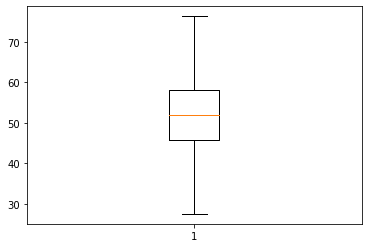

In [1174]:
plt.boxplot(df["VO2max"])

{'whiskers': [<matplotlib.lines.Line2D at 0x2000c5118b0>,
 'caps': [<matplotlib.lines.Line2D at 0x2000c511e50>,
 'boxes': [<matplotlib.lines.Line2D at 0x2000c511700>],
 'medians': [<matplotlib.lines.Line2D at 0x2000c520430>],
 'fliers': [<matplotlib.lines.Line2D at 0x2000c520700>],
 'means': []}

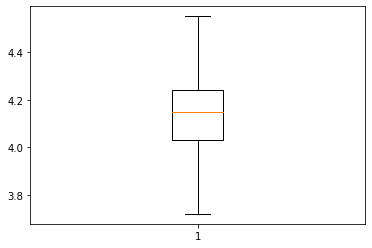

In [1175]:
plt.boxplot(df["Dinlenim_Nabzı_bpm"])

{'whiskers': [<matplotlib.lines.Line2D at 0x2000c569ee0>,
 'caps': [<matplotlib.lines.Line2D at 0x2000c5764c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2000c569d30>],
 'medians': [<matplotlib.lines.Line2D at 0x2000c576a60>],
 'fliers': [<matplotlib.lines.Line2D at 0x2000c576d30>],
 'means': []}

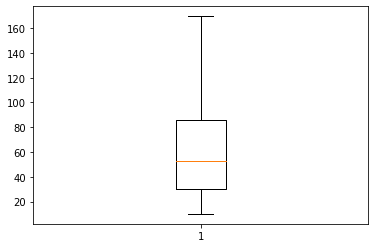

In [1176]:
plt.boxplot(df["Antrenman_Yükü_dk"])

{'whiskers': [<matplotlib.lines.Line2D at 0x2000c5d1c10>,
 'caps': [<matplotlib.lines.Line2D at 0x2000c5dd1f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2000c5d1ac0>],
 'medians': [<matplotlib.lines.Line2D at 0x2000c5dd790>],
 'fliers': [<matplotlib.lines.Line2D at 0x2000c5dda60>],
 'means': []}

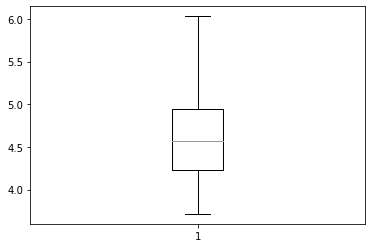

In [1177]:
plt.boxplot(df["Protein_Alımı_gr"])

{'whiskers': [<matplotlib.lines.Line2D at 0x2000c62fac0>,
 'caps': [<matplotlib.lines.Line2D at 0x2000c63c0a0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2000c621640>],
 'medians': [<matplotlib.lines.Line2D at 0x2000c63c640>],
 'fliers': [<matplotlib.lines.Line2D at 0x2000c63c910>],
 'means': []}

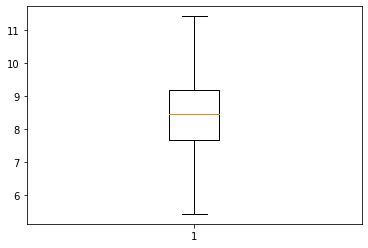

In [1178]:
plt.boxplot(df["Sporcu_Bütçe_TL"])

{'whiskers': [<matplotlib.lines.Line2D at 0x2000c68dac0>,
 'caps': [<matplotlib.lines.Line2D at 0x2000c69d0a0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2000c68d910>],
 'medians': [<matplotlib.lines.Line2D at 0x2000c69d640>],
 'fliers': [<matplotlib.lines.Line2D at 0x2000c69d910>],
 'means': []}

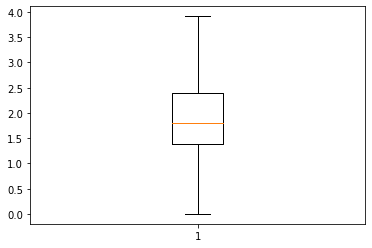

In [1179]:
plt.boxplot(df["Yarışma_Sayısı"])

In [1200]:
X = df.drop("Performans_Sınıfı", axis = 1)
Y = df["Performans_Sınıfı"]

In [1201]:
x_train, x_test, y_train, y_test = train_test_split(X,Y,
                                                   test_size=0.2,
                                                   random_state=42)

In [1202]:
skaler = StandardScaler()
sutunlar = ["Yaş","Boy_cm","Kilo_kg","VO2max","Dinlenim_Nabzı_bpm","Uyku_Saat","Antrenman_Yükü_dk",
           "Protein_Alımı_gr","Sporcu_Bütçe_TL","Yarışma_Sayısı"] 
x_train[sutunlar] = skaler.fit_transform(x_train[sutunlar])
x_test[sutunlar] = skaler.transform(x_test[sutunlar])

In [1203]:
x_train

,Deneyim_Yılı,Cinsiyet,Motivasyon_Düzeyi,Antrenman_Sıklığı,Rakip_Seviyesi,Yaş,Boy_cm,Kilo_kg,VO2max,Dinlenim_Nabzı_bpm,...,Kulüp_Tipi_Özel Kulüp,Kulüp_Tipi_Üniversite,Beslenme_Tipi_Standart,Beslenme_Tipi_Vegan,Beslenme_Tipi_Vejetaryen,Beslenme_Tipi_Yüksek Protein,Antrenman_Yeri_Ev,Antrenman_Yeri_Kapalı Salon,Antrenman_Yeri_Karma,Antrenman_Yeri_Profesyonel Tesis
145,3,0,4.0,2,1,-0.508513,0.890757,-0.126105,0.111143,-0.280749,...,0,0,0,0,1,0,1,0,0,0
9,2,1,4.0,1,2,-0.156801,-0.145074,0.924557,-1.027517,1.228133,...,0,0,0,0,1,0,0,0,0,1
376,3,1,1.0,1,2,0.714212,-1.011586,-0.238121,-1.237270,-0.439903,...,1,0,1,0,0,0,0,0,1,0
523,3,0,3.0,3,3,0.040869,-0.643069,0.131702,-0.558070,0.976511,...,0,0,1,0,0,0,0,1,0,0
188,4,1,3.0,1,3,-1.537430,0.641759,-0.192975,0.400802,-0.197502,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,3,1,0.0,2,1,0.984197,-0.473751,1.720441,-1.496964,0.222159,...,1,0,0,0,0,0,0,0,0,0
106,1,1,3.0,3,2,0.742290,0.562080,-2.350131,2.438403,-0.146033,...,0,0,0,0,0,0,1,0,0,0
271,0,1,4.0,3,2,1.073386,0.392762,0.131702,0.051213,-0.759647,...,0,0,0,0,0,0,0,0,0,1
436,2,1,3.0,4,2,-1.768166,1.727390,0.261915,-1.826576,-0.034277,...,0,0,1,0,0,0,1,0,0,0


In [1204]:
df.isnull().sum()

Deneyim_Yılı                        0
Cinsiyet                            0
Motivasyon_Düzeyi                   0
Antrenman_Sıklığı                   0
Rakip_Seviyesi                      0
Yaş                                 0
Boy_cm                              0
Kilo_kg                             0
VO2max                              0
Dinlenim_Nabzı_bpm                  0
Uyku_Saat                           0
Antrenman_Yükü_dk                   0
Sakatlık_Gün_Yıl                    0
Protein_Alımı_gr                    0
Sporcu_Bütçe_TL                     0
Yarışma_Sayısı                      0
Performans_Sınıfı                   0
Kulüp_Tipi_Devlet Kulübü            0
Kulüp_Tipi_Milli Takım              0
Kulüp_Tipi_diger                    0
Kulüp_Tipi_Özel Kulüp               0
Kulüp_Tipi_Üniversite               0
Beslenme_Tipi_Standart              0
Beslenme_Tipi_Vegan                 0
Beslenme_Tipi_Vejetaryen            0
Beslenme_Tipi_Yüksek Protein        0
Antrenman_Ye

In [1205]:
x_train.isnull().sum()

Deneyim_Yılı                        0
Cinsiyet                            0
Motivasyon_Düzeyi                   0
Antrenman_Sıklığı                   0
Rakip_Seviyesi                      0
Yaş                                 0
Boy_cm                              0
Kilo_kg                             0
VO2max                              0
Dinlenim_Nabzı_bpm                  0
Uyku_Saat                           0
Antrenman_Yükü_dk                   0
Sakatlık_Gün_Yıl                    0
Protein_Alımı_gr                    0
Sporcu_Bütçe_TL                     0
Yarışma_Sayısı                      0
Kulüp_Tipi_Devlet Kulübü            0
Kulüp_Tipi_Milli Takım              0
Kulüp_Tipi_diger                    0
Kulüp_Tipi_Özel Kulüp               0
Kulüp_Tipi_Üniversite               0
Beslenme_Tipi_Standart              0
Beslenme_Tipi_Vegan                 0
Beslenme_Tipi_Vejetaryen            0
Beslenme_Tipi_Yüksek Protein        0
Antrenman_Yeri_Ev                   0
Antrenman_Ye

In [1206]:
lr_model = LogisticRegression(max_iter=100)
lr_model.fit(x_train, y_train)
lr_pred = lr_model.predict(x_test)
lr_acc = accuracy_score(y_test, lr_pred)
lr_acc

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.3333333333333333

In [1207]:
siniflandirma_raporu = classification_report(y_test, lr_pred)
print(siniflandirma_raporu)

              precision    recall  f1-score   support

           0       0.33      0.49      0.40        35
           1       0.27      0.43      0.33        30
           2       0.50      0.26      0.35        34
           3       0.33      0.05      0.08        21

    accuracy                           0.33       120
   macro avg       0.36      0.31      0.29       120
weighted avg       0.36      0.33      0.31       120



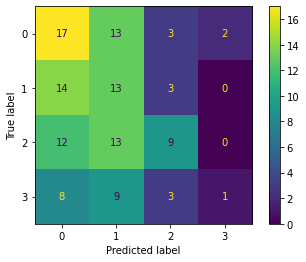

In [1208]:
con_matris = confusion_matrix(y_test, lr_pred)
gorsel = ConfusionMatrixDisplay(con_matris, display_labels=sorted(y_train.unique()))
gorsel.plot()

In [1209]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [1210]:
dt_model = DecisionTreeClassifier(max_depth=10)
dt_model.fit(x_train, y_train)
dt_pred = dt_model.predict(x_test)
dt_acc = accuracy_score(y_test, dt_pred)
dt_acc

0.26666666666666666

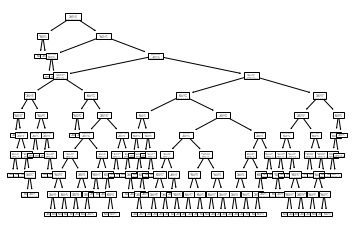

In [1211]:
plot_tree(dt_model);

In [ ]:
#defne uçar - 231619167